In [1]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# this for time series
#import statsmodels.formula.api as smf
#from statsmodels.tsa.seasonal import seasonal_decompose
#from scipy.ndimage import gaussian_filter
#from calendar import monthrange
#from calendar import month_name
#from sklearn.metrics import mean_squared_error
#from math import sqrt
#from statsmodels.tsa.stattools import adfuller,kpss
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
#from statsmodels.graphics.tsaplots import plot_pacf
#from pmdarima.arima import auto_arima
#import statsmodels.graphics.tsaplots as tsaplot
#from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#import tensorflow as tf
#from keras.models import Sequential
#from keras.layers import LSTM, Dense

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import load_model
import time


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

### Here we set the function for line plot  

In [2]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



In [3]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [4]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [5]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()'

In [6]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [7]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [8]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [9]:
#data_df_mwh.columns^

#### Unit conversion from 'mwh' to 'gwh' 

In [10]:
data_df_gwh = data_df_mwh.copy()

In [11]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [12]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [13]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [14]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [15]:
data_df_gwh.head()  

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [16]:
data_df= data_df_gwh.copy()

In [17]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [18]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


- The target is fixed here. We can run the cell for any desirable y-axis data

In [19]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
main_0  = 'Total_energy_generation_gwh' # This is only for energy
#main_0  = 'Solar_gwh' # for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Total energy generation in GWh
Total energy generation(GWh)


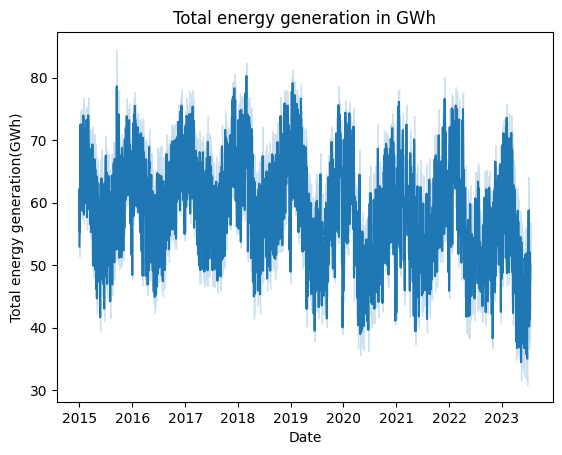

In [20]:
# Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [21]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [22]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [23]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

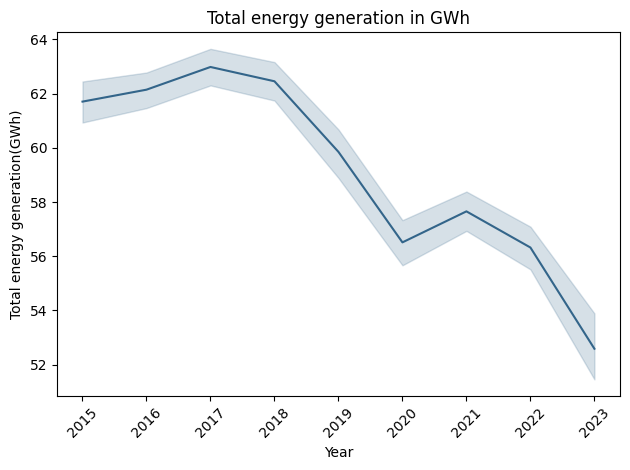

In [24]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [25]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [26]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Total_energy_generation_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,51.45925
2015-01-01,2015,1,1,1,1,49.98825
2015-01-01,2015,1,1,1,2,49.26525
2015-01-01,2015,1,1,1,3,48.53800
2015-01-01,2015,1,1,1,4,48.63000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,55.58000
2023-07-17,2023,7,17,198,19,50.83350
2023-07-17,2023,7,17,198,20,46.67225


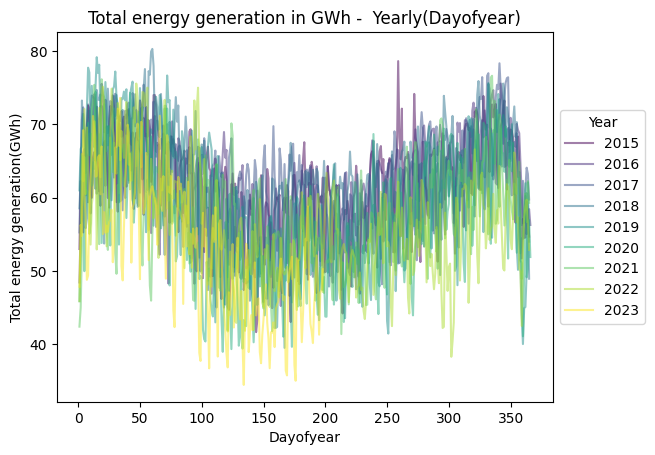

In [27]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [28]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [29]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

### Creating train and test sets
We will split our data and take the first part as our training set and the years after 2016 as a test set. Since we are dealing with a time series here we cannot split randomly as we are used to do. 

In [30]:
# Split data into train and test set
#window=365#*24
#df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_arima = df_arima.dropna()
#

#df_arima = data_df[target]
#train_test_split_ratio = int(len(df_arima)*0.8)
#train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

# Plotting the train and test set
#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(train_data, 'red', label='Train data')
#plt.plot(test_data, 'black', label='Test data')
#plt.legend()
#plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))

In [31]:
dfs = data_df[['Date',  target]]

## New test 

In [32]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Sort the DataFrame by date in ascending order
dfs = dfs.sort_values(by='Date', ascending=True)

# Create dataframe
data = dfs.copy()

# Redefine number of input time sequential steps
num = 7

# Set index
data.index = data.Date
data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(data) * 0.8)
train, valid = data.iloc[:train_size], data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=100, batch_size=5, verbose=2)
    history.append(h.history['loss'])

# Prepare validation data for predictions
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

# Make predictions on the validation set
closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_123/1620947312.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/100
1998/1998 - 7s - loss: 0.0076 - 7s/epoch - 3ms/step
Epoch 2/100
1998/1998 - 5s - loss: 0.0051 - 5s/epoch - 2ms/step
Epoch 3/100
1998/1998 - 5s - loss: 0.0049 - 5s/epoch - 2ms/step
Epoch 4/100
1998/1998 - 5s - loss: 0.0048 - 5s/epoch - 2ms/step
Epoch 5/100
1998/1998 - 5s - loss: 0.0047 - 5s/epoch - 2ms/step
Epoch 6/100
1998/1998 - 5s - loss: 0.0047 - 5s/epoch - 2ms/step
Epoch 7/100
1998/1998 - 5s - loss: 0.0047 - 5s/epoch - 2ms/step
Epoch 8/100
1998/1998 - 5s - loss: 0.0047 - 5s/epoch - 2ms/step
Epoch 9/100
1998/1998 - 5s - loss: 0.0046 - 5s/epoch - 2ms/step
Epoch 10/100
1998/1998 - 5s - loss: 0.0046 - 5s/epoch - 2ms/step
Epoch 11/100
1998/1998 - 5s - loss: 0.0046 - 5s/epoch - 2ms/step
Epoch 12/100
1998/1998 - 5s - loss: 0.0046 - 5s/epoch - 2ms/step
Epoch 13/100
1998/1998 - 5s - loss: 0.0046 - 5s/epoch - 2ms/step
Epoch 14/100
1998/1998 - 5s - loss: 0.0045 - 5s/epoch - 2ms/step
Epoch 15/100
1998/1998 - 5s - loss: 0.0045 - 5s/epoch - 3ms/step
Epoch 16/100
1998/1998 - 5s - loss

KeyboardInterrupt: 

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_75802/2240919732.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/50
999/999 - 16s - loss: 0.0042 - 16s/epoch - 16ms/step
Epoch 2/50
999/999 - 13s - loss: 9.7550e-04 - 13s/epoch - 13ms/step
Epoch 3/50
999/999 - 13s - loss: 5.3259e-04 - 13s/epoch - 13ms/step
Epoch 4/50
999/999 - 12s - loss: 3.6287e-04 - 12s/epoch - 12ms/step
Epoch 5/50
999/999 - 12s - loss: 3.1257e-04 - 12s/epoch - 12ms/step
Epoch 6/50
999/999 - 12s - loss: 2.9467e-04 - 12s/epoch - 12ms/step
Epoch 7/50
999/999 - 12s - loss: 2.9212e-04 - 12s/epoch - 12ms/step
Epoch 8/50
999/999 - 13s - loss: 2.9168e-04 - 13s/epoch - 13ms/step
Epoch 9/50
999/999 - 12s - loss: 2.7036e-04 - 12s/epoch - 12ms/step
Epoch 10/50
999/999 - 13s - loss: 2.7546e-04 - 13s/epoch - 13ms/step
Epoch 11/50
999/999 - 12s - loss: 2.7143e-04 - 12s/epoch - 12ms/step
Epoch 12/50
999/999 - 12s - loss: 2.6404e-04 - 12s/epoch - 12ms/step
Epoch 13/50
999/999 - 11s - loss: 2.5451e-04 - 11s/epoch - 11ms/step
Epoch 14/50
999/999 - 12s - loss: 2.5189e-04 - 12s/epoch - 12ms/step
Epoch 15/50
999/999 - 13s - loss: 2.4926e-04 - 

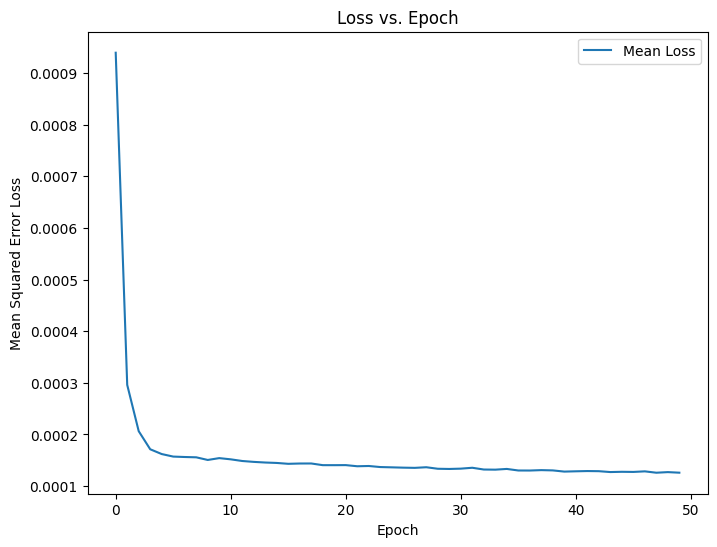

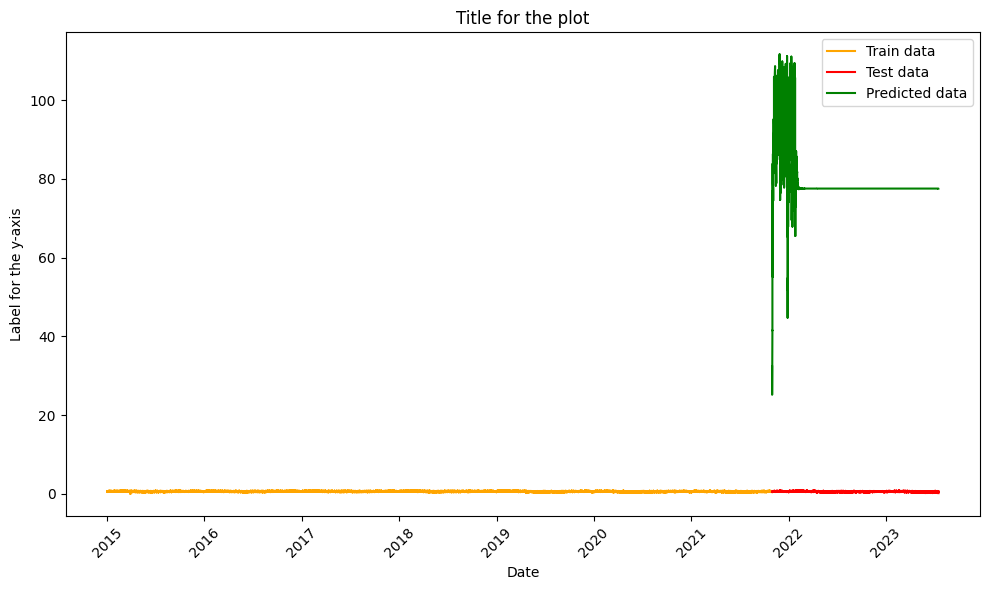

In [134]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Creating dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
for i in range(0, len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# Redefine num= 
#Input Sequence Length: The purpose of num is to determine the length of the input sequences that will be fed into the LSTM model during training.
num = 30

# Setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(new_data) * 0.8)
train, valid = new_data.iloc[:train_size], new_data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=50, batch_size=10, verbose=2)
    history.append(h.history['loss'])

# Predict on the validation set
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train_scaled, 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid_scaled, 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
#above to it 27.07.2023 look above this cell

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_75802/1745574190.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs ['Date'])


Epoch 1/40
2995/2995 [==============================] - 8s 2ms/step - loss: 0.0148
Epoch 2/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0120
Epoch 3/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
Epoch 4/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
Epoch 5/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
Epoch 6/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
Epoch 7/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
Epoch 8/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
Epoch 9/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
Epoch 10/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
Epoch 11/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
Epoch 12/40
2995/2995 [==============================] - 6s 2ms/step - loss: 0.0119
E

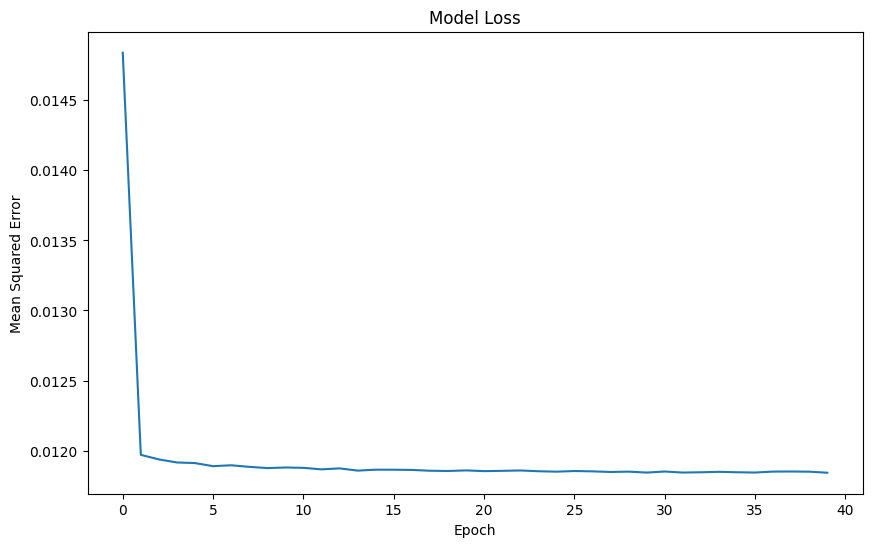

468/468 [==============================] - 1s 804us/step


ValueError: Found array with dim 3. None expected <= 2.

In [67]:

dfs = data_df[['Date',  target]]

# Convert 'Date' column to proper datetime format
dfs['Date'] = pd.to_datetime(dfs ['Date'])

# Set 'Date' column as the index and sort the DataFrame
dfs.set_index('Date', inplace=True)
dfs.sort_index(ascending=True, axis=0, inplace=True)

# Redefine 'num' variable
num = 10  # Assuming you want to use 60 past time steps for prediction

# Create a new DataFrame for data
new_data = dfs[[target]].copy()

# Normalizing the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(new_data)

# Prepare the training data
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

def create_dataset(data, num):
    X, y = [], []
    for i in range(num, len(data)):
        X.append(data[i - num:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

x_train, y_train = create_dataset(train, num)
x_test, y_test = create_dataset(test, num)

# Reshape the data for LSTM input (samples, timesteps, features)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Create and compile the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
history = model.fit(x_train, y_train, epochs=40, batch_size=20, verbose=1)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.show()

# Make predictions on the test set
closing_price = model.predict(x_test)
closing_price = scaler.inverse_transform(closing_price)

# Calculate evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(scaler.inverse_transform(y_test.reshape(-1, 1)), closing_price))
mae = mean_absolute_error(scaler.inverse_transform(y_test.reshape(-1, 1)), closing_price)
r2 = r2_score(scaler.inverse_transform(y_test.reshape(-1, 1)), closing_price)

print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

# Plot the predictions
plt.figure(figsize=(10, 6))
plt.plot(scaler.inverse_transform(y_test.reshape(-1, 1)), label='Actual', color='red')
plt.plot(closing_price, label='Predicted', color='green')
plt.xlabel('Time')
plt.ylabel('Target Value')
plt.title('Actual vs. Predicted')
plt.legend()
plt.show()

In [32]:
#print(dfs.shape)
#plt.figure()
#plt.plot(dfs['Date'], dfs[target])
#plt.autoscale(enable=True, axis='x', tight=True)
#plt.show();

In [ ]:
#### Simple method

In [58]:
# 'Date' format y-m-d
# Create a new column for the x-axis values
dfs['x_axis'] = dfs['Date'].apply(lambda x: x.timestamp())

# Split the data into train and test sets
train_df = dfs[:int(len(dfs)*0.8)]
test_df = dfs[int(len(dfs)*0.8):]

# Create the X and y arrays for training and testing
X_train = np.array(train_df['x_axis'])
y_train = np.array(train_df[target])
X_test = np.array(test_df['x_axis'])
y_test = np.array(test_df[target])

# Reshape the X arrays to 3D
X_train = np.reshape(X_train, (X_train.shape[0], 1, 1))
X_test = np.reshape(X_test, (X_test.shape[0], 1, 1))

# Create the model
model = Sequential()
model.add(LSTM(50, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Fit the model
model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=2)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_73068/2038719611.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['x_axis'] = dfs['Date'].apply(lambda x: x.timestamp())


Epoch 1/100
59903/59903 - 29s - loss: 226.2178 - 29s/epoch - 487us/step
Epoch 2/100
59903/59903 - 34s - loss: 113.6416 - 34s/epoch - 569us/step
Epoch 3/100
59903/59903 - 30s - loss: 113.6416 - 30s/epoch - 509us/step
Epoch 4/100
59903/59903 - 31s - loss: 113.6455 - 31s/epoch - 523us/step
Epoch 5/100
59903/59903 - 31s - loss: 113.6387 - 31s/epoch - 511us/step
Epoch 6/100
59903/59903 - 32s - loss: 113.6558 - 32s/epoch - 527us/step
Epoch 7/100
59903/59903 - 32s - loss: 113.6350 - 32s/epoch - 538us/step
Epoch 8/100
59903/59903 - 30s - loss: 113.6346 - 30s/epoch - 497us/step
Epoch 9/100
59903/59903 - 30s - loss: 113.6384 - 30s/epoch - 500us/step
Epoch 10/100
59903/59903 - 31s - loss: 113.6446 - 31s/epoch - 514us/step
Epoch 11/100
59903/59903 - 31s - loss: 113.6518 - 31s/epoch - 512us/step
Epoch 12/100
59903/59903 - 28s - loss: 113.6468 - 28s/epoch - 472us/step
Epoch 13/100
59903/59903 - 31s - loss: 113.6542 - 31s/epoch - 524us/step
Epoch 14/100
59903/59903 - 30s - loss: 115.1157 - 30s/epoch 

In [61]:
# Calculate RMSE, MSE, MAE, R2
rmse_train = np.sqrt(mean_squared_error(y_train, train_predict))
mse_train = mean_squared_error(y_train, train_predict)
mae_train = mean_absolute_error(y_train, train_predict)
r2_train = r2_score(y_train, train_predict)

print("Root Mean Squared Error:", rmse_train)
print("Mean Squared Error:", mse_train)
print("Mean Absolute Error:", mae_train)
print("R^2:", r2_train)



Root Mean Squared Error: 10.657847657799822
Mean Squared Error: 113.58971669686916
Mean Absolute Error: 8.826724035459296
R^2: -0.00012937545937363737


#### Method 1

In [43]:

# 'Date' format y-m-d
# Convert date to datetime format
#dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs['Date'] = dfs['Date'].apply(lambda x: x.timestamp())
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(dfs['Date'], dfs[target], test_size=0.2, random_state=42)

# Reshape data for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], 1, 1))
X_test = np.reshape(X_test, (X_test.shape[0], 1, 1))

# Create model
model = Sequential()
model.add(LSTM(50, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Fit model
model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=2)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Calculate RMSE, MSE, MAE, R2
rmse_train = np.sqrt(mean_squared_error(y_train, train_predict))
mse_train = mean_squared_error(y_train, train_predict)
mae_train = mean_absolute_error(y_train, train_predict)
r2_train = r2_score(y_train, train_predict)

print("Root Mean Squared Error:", rmse_train)
print("Mean Squared Error:", mse_train)
print("Mean Absolute Error:", mae_train)
print("R^2:", r2_train)





ValueError: x and y must have same first dimension, but have shapes (59903, 1, 1) and (14976, 1, 1)

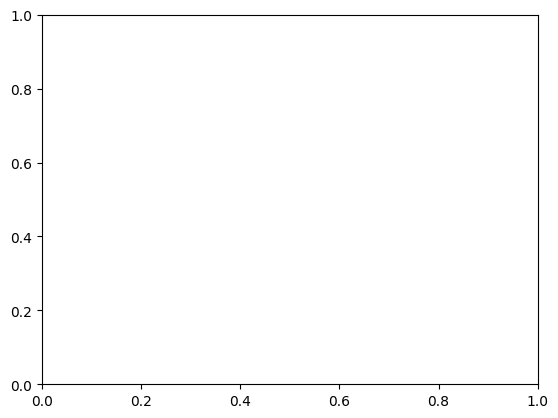

In [79]:

# Plot results
#plt.plot(X_train, y_train)
#plt.plot(X_train, train_predict)
plt.plot(X_train, X_test)
plt.legend()
plt.show()

## Please check this cell 

In [78]:
# 'Date' format y-m-d
#dfs = data_df[['Date',  target]]
# Assuming data_df contains your DataFrame with the 'Date' and 'target' columns
# If the 'Date' column is not in datetime format, uncomment the following line
# data_df['Date'] = pd.to_datetime(data_df['Date'])

# Convert the 'Date' column to numerical representation
data_df1['Date'] = (data_df['Date'] - data_df['Date'].min()).dt.days

dfs = data_df1[['Date', 'target']]

# Split the data into train and test sets
train_dfs = dfs[:int(len(dfs)*0.8)]
test_dfs = dfs[int(len(dfs)*0.8):]

# Create X and y variables for train and test sets
X_train = train_dfs['Date'].values
y_train = train_dfs['target'].values
X_test = test_dfs['Date'].values
y_test = test_dfs['target'].values

# Reshape X variables for LSTM model
X_train = np.reshape(X_train, (X_train.shape[0], 1, 1))
X_test = np.reshape(X_test, (X_test.shape[0], 1, 1))

# Create and fit the LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=200, batch_size=2, verbose=2)

# Make predictions on the test set
predictions = model.predict(X_test)

# Calculate RMSE, MSE, MAE and R2 scores
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Print the scores
print('RMSE: ', rmse)
print('MSE: ', mse)
print('MAE: ', mae)
print('R2: ', r2)

# Plot the results
plt.plot(test_dfs['Date'], y_test, label='Test Data')
plt.plot(test_dfs['Date'], predictions, label='Predicted Data')
plt.plot(train_dfs['Date'], y_train, label='Train Data')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.show()

array([51.45925, 49.98825, 49.26525, ..., 62.198  , 60.8285 , 58.65075])

#### Method 2

In [46]:
# 'Date' format y-m-d
#dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs['Date'] = dfs['Date'].apply(lambda x: x.timestamp())
# Split the data into train and test sets
train_dfs = dfs[:int(len(dfs)*0.8)]
test_dfs = dfs[int(len(dfs)*0.8):]

# Create X and y variables for train and test sets
X_train = train_dfs['Date'].values
y_train = train_dfs[target].values
X_test = test_dfs['Date'].values
y_test = test_dfs[target].values

# Reshape X variables for LSTM model
X_train = np.reshape(X_train, (X_train.shape[0], 1, 1))
X_test = np.reshape(X_test, (X_test.shape[0], 1, 1))

# Create and fit the LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=200, batch_size=2, verbose=2)

# Make predictions on the test set
predictions = model.predict(X_test)

# Calculate RMSE, MSE, MAE and R2 scores
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Print the scores
print('RMSE: ', rmse)
print('MSE: ', mse)
print('MAE: ', mae)
print('R2: ', r2)

# Plot the results
plt.plot(X_test, y_test, label='Test Data')
plt.plot(X_test, predictions, label='Predicted Data')
plt.plot(X_train, y_train, label='Train Data')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.show()

ValueError: Failed to convert a NumPy array to a Tensor (Unsupported numpy type: NPY_DATETIME).

Epoch 1/10
59893/59893 - 261s - loss: 5.1649e-04 - 261s/epoch - 4ms/step
Epoch 2/10
59893/59893 - 253s - loss: 2.7144e-04 - 253s/epoch - 4ms/step
Epoch 3/10
59893/59893 - 233s - loss: 2.5767e-04 - 233s/epoch - 4ms/step
Epoch 4/10
59893/59893 - 225s - loss: 2.3694e-04 - 225s/epoch - 4ms/step
Epoch 5/10
59893/59893 - 223s - loss: 2.2201e-04 - 223s/epoch - 4ms/step
Epoch 6/10
59893/59893 - 213s - loss: 2.1683e-04 - 213s/epoch - 4ms/step
Epoch 7/10
59893/59893 - 221s - loss: 2.1006e-04 - 221s/epoch - 4ms/step
Epoch 8/10
59893/59893 - 220s - loss: 2.0518e-04 - 220s/epoch - 4ms/step
Epoch 9/10
59893/59893 - 221s - loss: 2.0394e-04 - 221s/epoch - 4ms/step
Epoch 10/10
59893/59893 - 219s - loss: 2.0031e-04 - 219s/epoch - 4ms/step
468/468 [==============================] - 2s 2ms/step


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_75802/2045148049.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = closing_price


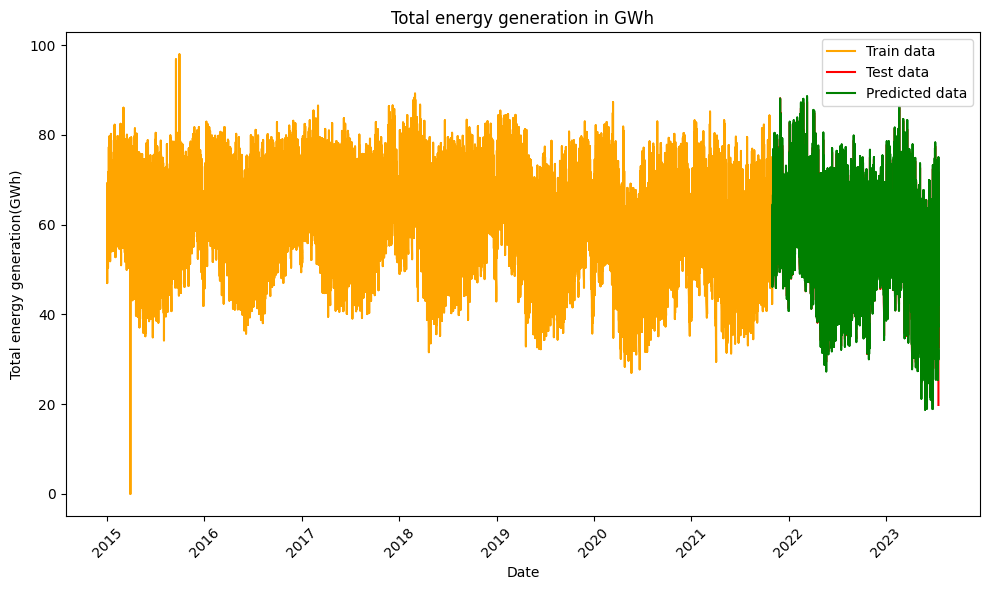

In [32]:
dfs = data_df[['Date',  target]]

#creating dataframe
data = dfs.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0,len(dfs)),columns=['Date', target])
for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# Redefine num= 60 origional
num=10

#setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

#creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset)*0.8),:]
valid = dataset[int(len(dataset)*0.8):,:]

#converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(num,len(train)):
    x_train.append(scaled_data[i-num:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=10, batch_size=1, verbose=2)

#predicting 246 values, using past 60 from the train data
inputs = new_data[len(new_data) - len(valid) - num:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)


X_test = []
for i in range(num,inputs.shape[0]):
    X_test.append(inputs[i-num:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

#for plotting
train = new_data[:int(len(dataset)*0.8)]
valid = new_data[int(len(dataset)*0.8):]
valid['Predictions'] = closing_price
#plt.plot(train[target])
#plt.plot(valid[[target,'Predictions']])
#plt.show()

plt.figure(figsize=(10,6))
plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [33]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

Root Mean Squared Error: 1.4067563590084997
Mean Squared Error: 1.9789634536108507
Mean Absolute Error: 1.057111970199479
R^2: 0.9845547047694654


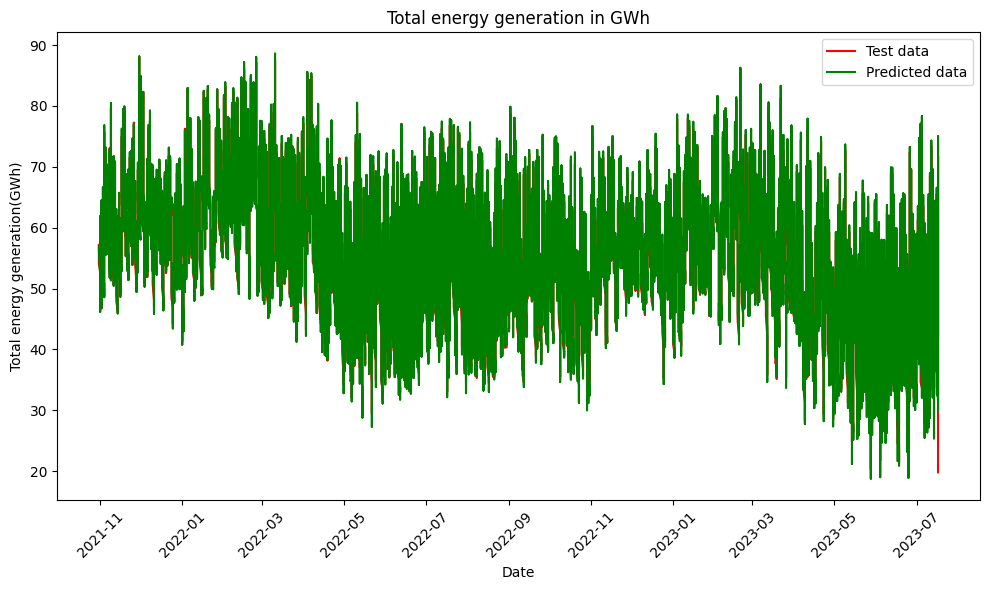

In [34]:
plt.figure(figsize=(10,6))
#plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

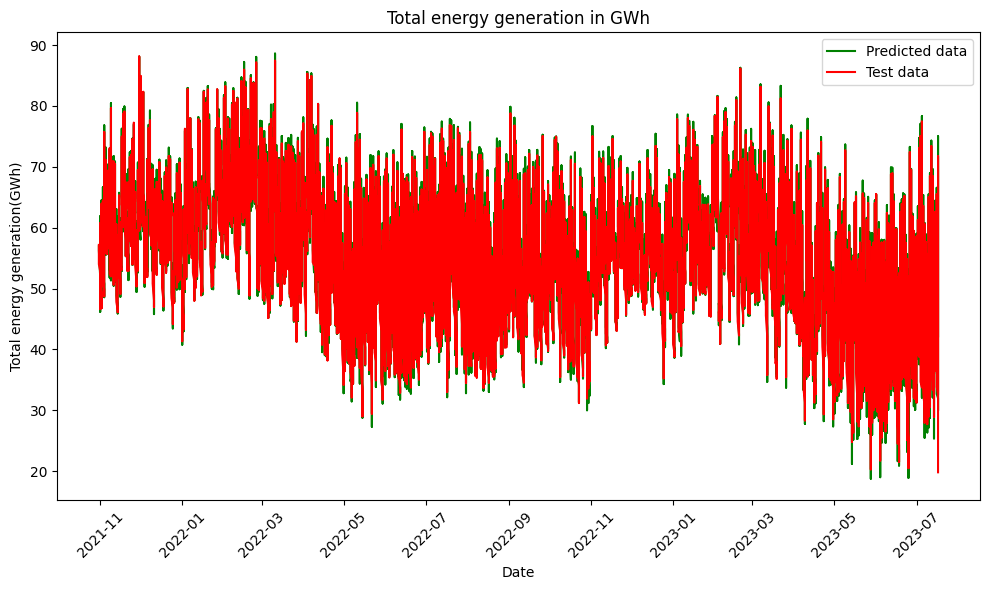

In [35]:
plt.figure(figsize=(10,6))
#plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.plot(valid[target],  'red', label='Test data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

Epoch 1/100
59893/59893 - 222s - loss: 4.9854e-04 - 222s/epoch - 4ms/step
Epoch 2/100
59893/59893 - 224s - loss: 2.7327e-04 - 224s/epoch - 4ms/step
Epoch 3/100
59893/59893 - 496s - loss: 2.5749e-04 - 496s/epoch - 8ms/step
Epoch 4/100
59893/59893 - 184s - loss: 2.4069e-04 - 184s/epoch - 3ms/step
Epoch 5/100
59893/59893 - 189s - loss: 2.2789e-04 - 189s/epoch - 3ms/step
Epoch 6/100
59893/59893 - 210s - loss: 2.1751e-04 - 210s/epoch - 4ms/step
Epoch 7/100
59893/59893 - 214s - loss: 2.1090e-04 - 214s/epoch - 4ms/step
Epoch 8/100
59893/59893 - 221s - loss: 2.0637e-04 - 221s/epoch - 4ms/step
Epoch 9/100
59893/59893 - 300s - loss: 2.0150e-04 - 300s/epoch - 5ms/step
Epoch 10/100
59893/59893 - 204s - loss: 1.9863e-04 - 204s/epoch - 3ms/step
Epoch 11/100
59893/59893 - 221s - loss: 1.9437e-04 - 221s/epoch - 4ms/step
Epoch 12/100
59893/59893 - 213s - loss: 1.9146e-04 - 213s/epoch - 4ms/step
Epoch 13/100
59893/59893 - 181s - loss: 1.8907e-04 - 181s/epoch - 3ms/step
Epoch 14/100
59893/59893 - 174s - 

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_75802/118018799.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = closing_price


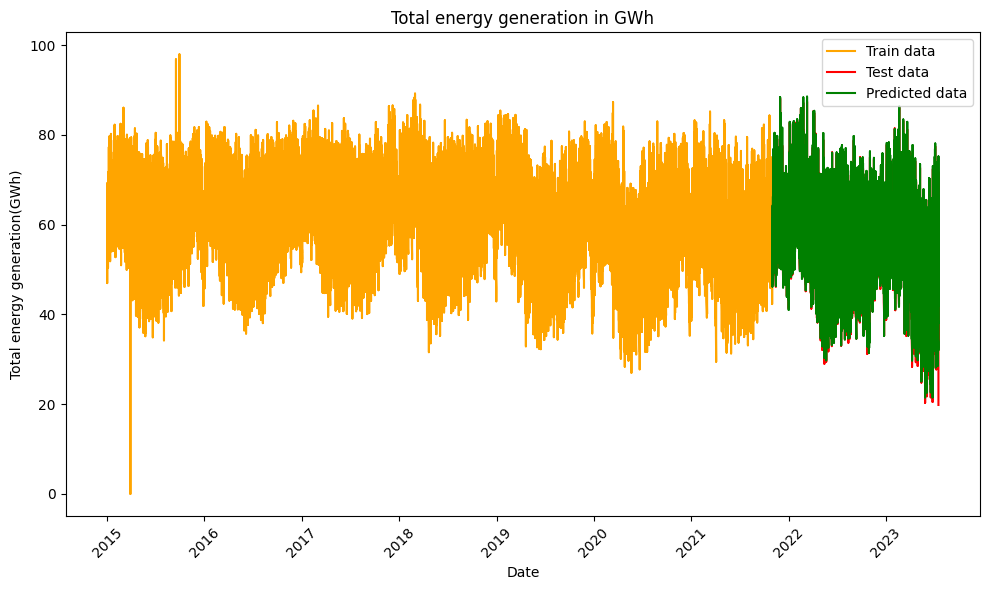

In [36]:
dfs = data_df[['Date',  target]]

#creating dataframe
data = dfs.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0,len(dfs)),columns=['Date', target])
for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# Redefine num= 60 origional
num=10

#setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

#creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset)*0.8),:]
valid = dataset[int(len(dataset)*0.8):,:]

#converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(num,len(train)):
    x_train.append(scaled_data[i-num:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=100, batch_size=1, verbose=2)

#predicting 246 values, using past 60 from the train data
inputs = new_data[len(new_data) - len(valid) - num:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)


X_test = []
for i in range(num,inputs.shape[0]):
    X_test.append(inputs[i-num:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

#for plotting
train = new_data[:int(len(dataset)*0.8)]
valid = new_data[int(len(dataset)*0.8):]
valid['Predictions'] = closing_price
#plt.plot(train[target])
#plt.plot(valid[[target,'Predictions']])
#plt.show()

plt.figure(figsize=(10,6))
plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
#plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()